# Лабораторная работа 1

Классификация **цвета автомобиля** по фронтальным изображениям из датасета DVM.  
Нужно обучить 3 модели и сравнить **F1_macro** на тесте (порог > 0.8).


## Настройки

Пути к папкам с картинками и куда сохранять сплиты/веса.  
Гиперпараметры обучения: размер батча, learning rate, seed для воспроизводимости.


In [12]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet50_Weights, DenseNet121_Weights, resnet50, densenet121
from tqdm import tqdm

BASE = Path(".").resolve()
DATA_DIR = BASE / "dataset" / "confirmed_fronts"
OUT_DIR = BASE / "workspace" / "data"
RUNS_DIR = BASE / "workspace" / "runs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 1612
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
LR = 3e-4
WEIGHT_DECAY = 1e-4

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def load_checkpoint(path, map_location=None):
    """Свои best.pt из train_net (в pickle есть numpy-скаляры; PyTorch 2.6+ по умолчанию weights_only=True)."""
    kwargs = {"map_location": map_location}
    try:
        return torch.load(path, weights_only=False, **kwargs)
    except TypeError:
        return torch.load(path, **kwargs)


## Разбор метки «цвет»

В имени файла DVM цвет обычно идёт после разделителя `$$` (четвёртое поле в имени).  
Разные написания (grey и gray, navy и blue) приводим к одному классу — словарь `COLOR_FIX`.


In [2]:
COLOR_FIX = {
    "grey": "gray",
    "dark grey": "dark_gray",
    "darkgray": "dark_gray",
    "light grey": "light_gray",
    "lightgray": "light_gray",
    "off white": "white",
    "offwhite": "white",
    "navy": "blue",
    "navy blue": "blue",
}

def normalize_color(name):
    s = name.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\([^)]*\)", " ", s).strip()
    s = re.sub(r"\s+", " ", s)
    if s in COLOR_FIX:
        return COLOR_FIX[s]
    key = s.replace(" ", "_")
    if key in COLOR_FIX:
        return COLOR_FIX[key]
    return key

def color_from_filename(path):
    stem = path.stem
    if "$$" in stem:
        parts = [p for p in stem.split("$$") if p]
        if len(parts) >= 4:
            return parts[3]
    return path.parent.name

def collect_images(root):
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXT:
            yield p


## Датасет и разбиение

`CarDataset` — загрузка картинки по пути из csv.  
`make_splits`: обход всех фото, таблица, **6 самых частых** цветов (минимум 30 фото на класс), разбиение train / val / test **70% / 15% / 15%** со стратификацией.


In [16]:
class CarDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

def make_splits(data_dir, out_dir, seed=42, test_size=0.15, val_size=0.15, top_k=6, min_count=30):
    set_seed(seed)
    rows = []
    for p in tqdm(list(collect_images(data_dir)), desc="сканирование"):
        raw = color_from_filename(p)
        color = normalize_color(raw)
        rows.append({"path": str(p.resolve()), "color": color})

    df = pd.DataFrame(rows)
    if df.empty or "color" not in df.columns:
        raise FileNotFoundError(
            f"В {data_dir} не найдено изображений ({IMG_EXT}).\n"
            "Загрузите DVM в dataset/confirmed_fronts "
            "Запускайте ноутбук из папки submit."
        )
    counts = Counter(df["color"])
    top = [c for c, _ in counts.most_common(top_k)]
    top = [c for c in top if counts[c] >= min_count]
    df = df[df["color"].isin(top)].copy()

    labels = sorted(df["color"].unique())
    label2id = {c: i for i, c in enumerate(labels)}
    df["label"] = df["color"].map(label2id)

    train_df, test_df = train_test_split(df, test_size=test_size, stratify=df["label"], random_state=seed)
    val_part = val_size / (1 - test_size)
    train_df, val_df = train_test_split(train_df, test_size=val_part, stratify=train_df["label"], random_state=seed)

    split_dir = out_dir / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
        part[["path", "label"]].to_csv(split_dir / f"{name}.csv", index=False)

    with open(out_dir / "labels.json", "w", encoding="utf-8") as f:
        json.dump({"labels": labels, "label2id": label2id}, f, ensure_ascii=False, indent=2)

    print(f"классов: {len(labels)}, train {len(train_df)}, val {len(val_df)}, test {len(test_df)}")
    return labels


## Модели

1. **scratch** — ResNet18, собранный вручную (BasicBlock + 4 stage), без предобучения.  
2. **resnet50** — torchvision, веса ImageNet, меняем только последний слой.  
3. **densenet121** — то же для DenseNet121.


In [4]:
def conv3x3(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)

class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, down=None):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = conv3x3(out_ch, out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.down = down
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        r = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        if self.down is not None:
            r = self.down(r)
        return self.relu(x + r)

class MyResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.in_ch = 64
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, ch, n, stride=1):
        down = None
        if stride != 1 or self.in_ch != ch:
            down = nn.Sequential(
                nn.Conv2d(self.in_ch, ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(ch),
            )
        layers = [BasicBlock(self.in_ch, ch, stride, down)]
        self.in_ch = ch
        for _ in range(1, n):
            layers.append(BasicBlock(self.in_ch, ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x).flatten(1)
        return self.fc(x)

def get_model(name, num_classes, pretrained=True):
    if name == "scratch":
        return MyResNet18(num_classes)
    if name == "resnet50":
        m = resnet50(weights=ResNet50_Weights.DEFAULT if pretrained else None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if name == "densenet121":
        m = densenet121(weights=DenseNet121_Weights.DEFAULT if pretrained else None)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        return m
    raise ValueError(name)


## Функции обучения

Аугментации для train (flip, лёгкий ColorJitter), для val/test — только resize и нормализация ImageNet.  

`run_epoch` — один проход по батчам (обучение или проверка).  
`train_net` — цикл по эпохам; история пишется в `history.json`, графики строятся ниже.


In [5]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

def run_epoch(model, loader, device, optimizer=None, criterion=None):
    train = optimizer is not None
    model.train(train)
    losses = []
    y_true, y_pred = [], []

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        else:
            with torch.no_grad():
                out = model(x)
                if criterion is not None:
                    losses.append(criterion(out, y).item())
        y_true.extend(y.cpu().tolist())
        y_pred.extend(out.argmax(1).cpu().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    loss_avg = float(np.mean(losses)) if losses else 0.0
    return loss_avg, acc, f1, y_true, y_pred

def plot_train_history(history, title):
    ep = [h["epoch"] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(ep, [h["train_loss"] for h in history], marker="o", markersize=3)
    axes[0].set_xlabel("эпоха")
    axes[0].set_ylabel("loss")
    axes[0].set_title("Train loss")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, [h["val_f1"] for h in history], marker="o", markersize=3, color="tab:green")
    axes[1].axhline(0.8, color="red", linestyle="--", linewidth=1, label="F1 = 0.8")
    axes[1].set_xlabel("эпоха")
    axes[1].set_ylabel("F1 macro")
    axes[1].set_title("Validation F1")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def train_net(name, epochs, pretrained=True):
    with open(OUT_DIR / "labels.json", encoding="utf-8") as f:
        meta = json.load(f)
    n_cls = len(meta["labels"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_df = pd.read_csv(OUT_DIR / "splits" / "train.csv")
    val_df = pd.read_csv(OUT_DIR / "splits" / "val.csv")

    train_loader = DataLoader(
        CarDataset(train_df, train_tf),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        CarDataset(val_df, test_tf),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    model = get_model(name, n_cls, pretrained=pretrained).to(device)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    crit = nn.CrossEntropyLoss()

    save_dir = RUNS_DIR / name
    save_dir.mkdir(parents=True, exist_ok=True)
    best_f1 = 0.0
    history = []

    for ep in range(1, epochs + 1):
        tr_loss, _, _, _, _ = run_epoch(model, train_loader, device, opt, crit)
        _, val_acc, val_f1, _, _ = run_epoch(model, val_loader, device, criterion=crit)
        history.append({"epoch": ep, "train_loss": tr_loss, "val_f1": val_f1})
        print(f"{name} эпоха {ep}/{epochs}: train loss {tr_loss:.4f}, val acc {val_acc:.4f}, F1 {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(
                {"model": name, "state_dict": model.state_dict(), "f1": float(val_f1)},
                save_dir / "best.pt",
            )

    with open(save_dir / "history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    return history


## Подготовка данных

Запускаем сканирование папки `dataset/confirmed_fronts`.  
Результат: csv-файлы сплитов и `labels.json` с номерами классов.  
Если меняете `top_k` или `SEED` — эту ячейку нужно выполнить заново.


In [6]:
labels = make_splits(
    DATA_DIR,
    OUT_DIR,
    seed=SEED,
    test_size=0.15,
    val_size=0.15,
    top_k=6,
    min_count=30,
)
labels


сканирование: 100%|██████████| 61827/61827 [00:14<00:00, 4407.48it/s]


классов: 6, train 38873, val 8331, test 8331


['black', 'blue', 'gray', 'red', 'silver', 'white']

## Распределение классов

Сколько примеров каждого цвета в train после фильтрации (top_k=6).


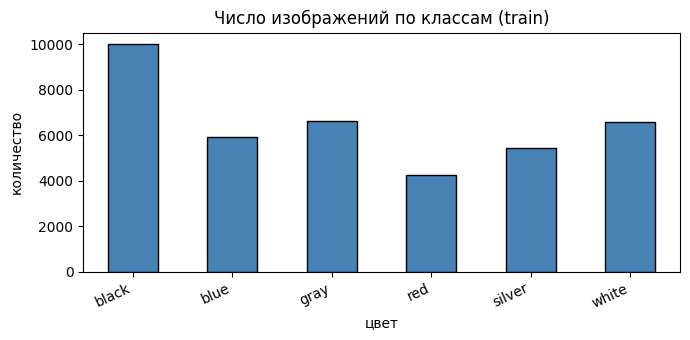

In [7]:
with open(OUT_DIR / "labels.json", encoding="utf-8") as f:
    label_names = json.load(f)["labels"]
name_by_id = {i: n for i, n in enumerate(label_names)}

train_df = pd.read_csv(OUT_DIR / "splits" / "train.csv")
counts = train_df["label"].map(name_by_id).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Число изображений по классам (train)")
ax.set_ylabel("количество")
ax.set_xlabel("цвет")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Обучение

По условию лабораторной:
- ResNet18 **с нуля** — 15 эпох;
- ResNet50 и DenseNet121 с **ImageNet** — по 10 эпох, fine-tuning всей сети.

Обучение может занять продолжительное время (зависит от GPU).


In [8]:
set_seed(SEED)
histories = {}

histories["scratch"] = train_net("scratch", epochs=10, pretrained=False)
histories["resnet50"] = train_net("resnet50", epochs=7, pretrained=True)
histories["densenet121"] = train_net("densenet121", epochs=7, pretrained=True)


scratch эпоха 1/10: train loss 0.6644, val acc 0.7429, F1 0.7478


scratch эпоха 2/10: train loss 0.4639, val acc 0.8133, F1 0.8291


scratch эпоха 3/10: train loss 0.4015, val acc 0.8365, F1 0.8440


scratch эпоха 4/10: train loss 0.3623, val acc 0.8794, F1 0.8806


scratch эпоха 5/10: train loss 0.3316, val acc 0.8931, F1 0.8952


...

densenet121 эпоха 3/7: train loss 0.2299, val acc 0.9334, F1 0.9343


densenet121 эпоха 4/7: train loss 0.1961, val acc 0.9269, F1 0.9311


densenet121 эпоха 5/7: train loss 0.1713, val acc 0.9282, F1 0.9296


densenet121 эпоха 6/7: train loss 0.1518, val acc 0.9325, F1 0.9336


densenet121 эпоха 7/7: train loss 0.1289, val acc 0.9328, F1 0.9351


## Графики обучения

Loss на train и F1_macro на validation по эпохам.


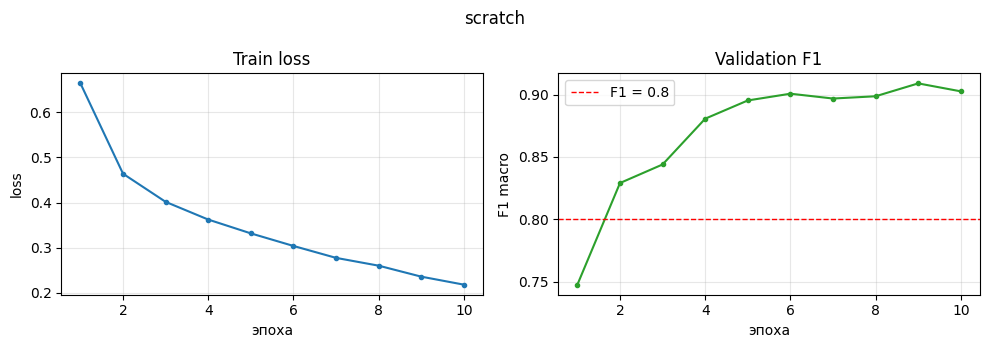

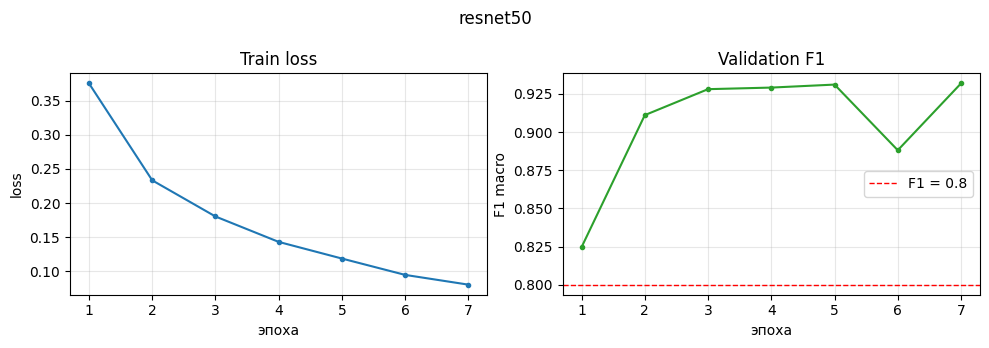

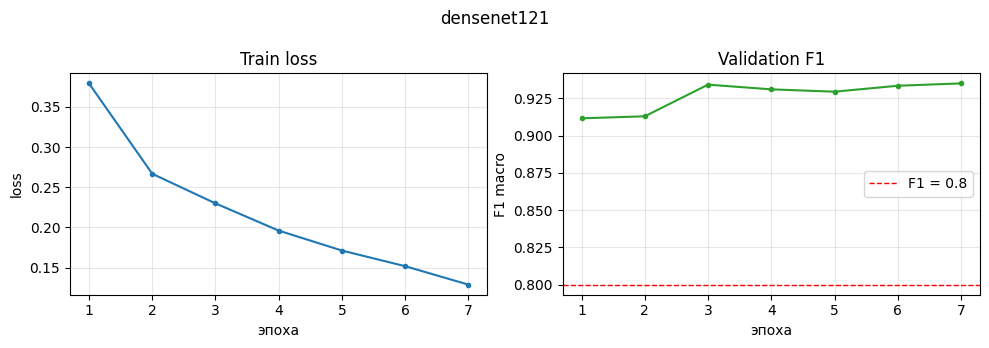

In [9]:
try:
    _ = histories
except NameError:
    histories = {}

for n in ["scratch", "resnet50", "densenet121"]:
    if n not in histories and (RUNS_DIR / n / "history.json").exists():
        with open(RUNS_DIR / n / "history.json", encoding="utf-8") as f:
            histories[n] = json.load(f)

for name, hist in histories.items():
    plot_train_history(hist, title=name)


## Оценка на test

Таблица метрик, столбчатый график F1 и матрицы ошибок.


      model      acc  f1_macro
   resnet50 0.933861  0.935287
densenet121 0.928820  0.930086
    scratch 0.905774  0.907312


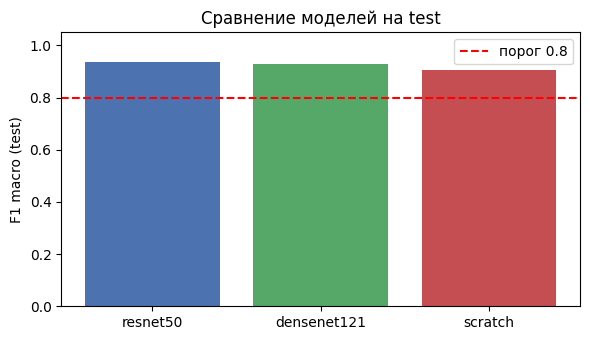

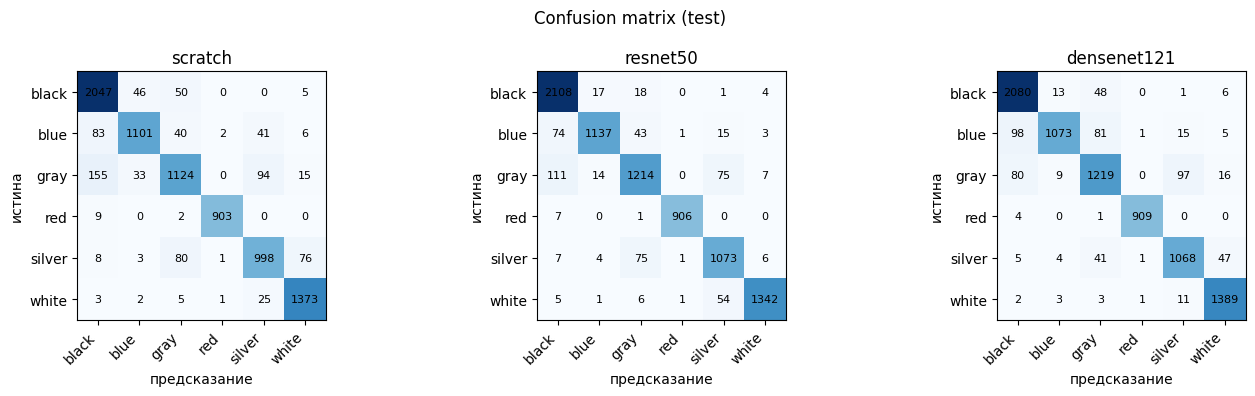

In [17]:
def eval_on_test(name):
    with open(OUT_DIR / "labels.json", encoding="utf-8") as f:
        meta = json.load(f)
    n_cls = len(meta["labels"])
    label_names = meta["labels"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    df = pd.read_csv(OUT_DIR / "splits" / "test.csv")
    loader = DataLoader(
        CarDataset(df, test_tf),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    model = get_model(name, n_cls, pretrained=False).to(device)
    ckpt = load_checkpoint(RUNS_DIR / name / "best.pt", map_location=device)
    model.load_state_dict(ckpt["state_dict"])

    _, acc, f1, y_true, y_pred = run_epoch(model, loader, device, criterion=nn.CrossEntropyLoss())
    return acc, f1, y_true, y_pred, label_names

rows = []
test_preds = {}
for name in ["scratch", "resnet50", "densenet121"]:
    acc, f1, y_true, y_pred, label_names = eval_on_test(name)
    rows.append({"model": name, "acc": acc, "f1_macro": f1})
    test_preds[name] = (y_true, y_pred)

result = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
print(result.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#4c72b0", "#55a868", "#c44e52"]
ax.bar(result["model"], result["f1_macro"], color=colors[: len(result)])
ax.axhline(0.8, color="red", linestyle="--", label="порог 0.8")
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 macro (test)")
ax.set_title("Сравнение моделей на test")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ["scratch", "resnet50", "densenet121"]):
    y_true, y_pred = test_preds[name]
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks(range(len(label_names)), label_names, rotation=45, ha="right")
    ax.set_yticks(range(len(label_names)), label_names)
    ax.set_xlabel("предсказание")
    ax.set_ylabel("истина")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)
fig.suptitle("Confusion matrix (test)")
plt.tight_layout()
plt.show()


## Вывод

- какая модель дала наибольший F1_macro на test;
- выполнено ли требование **F1_macro > 0.8**;
- чем pretrained-модели отличаются от сети, обученной с нуля;
- что можно улучшить (больше эпох, другие классы и т.д.).
